# Exploratory Data Analysis

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_PATH = BASE_DIR / "Dataset" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
TARGET_COL='Churn'

df=pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


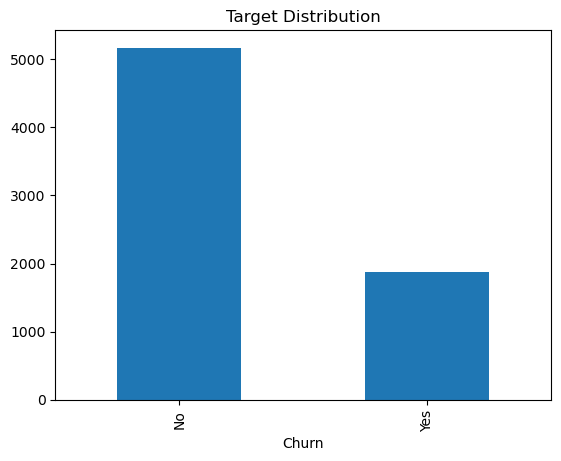

In [3]:
# Target Distribution
df[TARGET_COL].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.show()


In [4]:
# Missing Values
missing=(df.isnull().mean()*100)
missing=missing[missing>0].sort_values(ascending=False)
if len(missing):
    plt.bar(missing.index, missing.values)
    plt.xticks(rotation=90)
    plt.show()


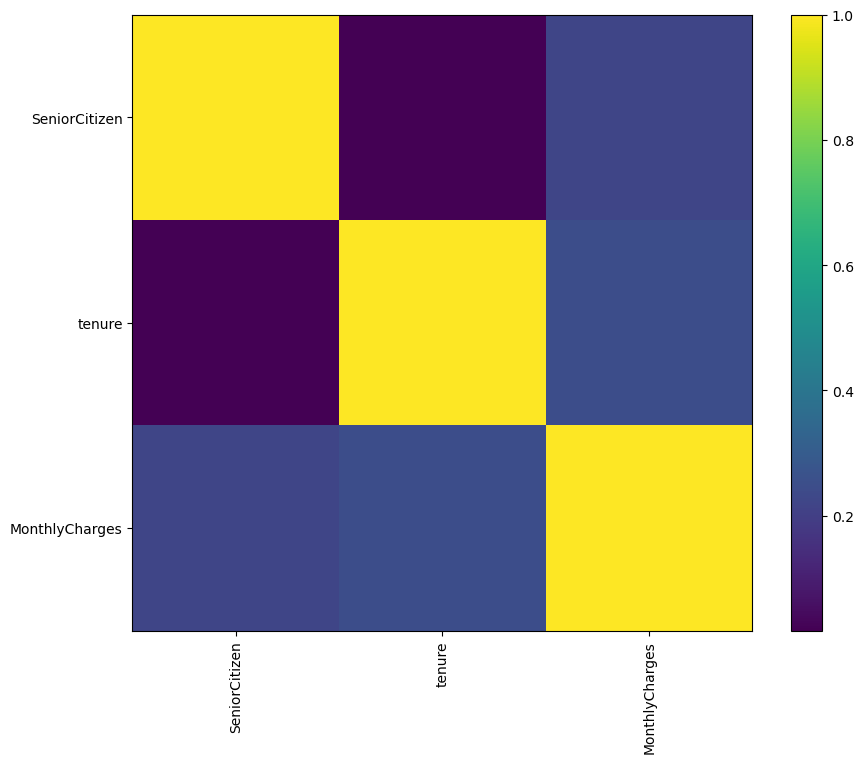

In [5]:
# Correlation Matrix
num=df.select_dtypes(include=np.number)
corr=num.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()


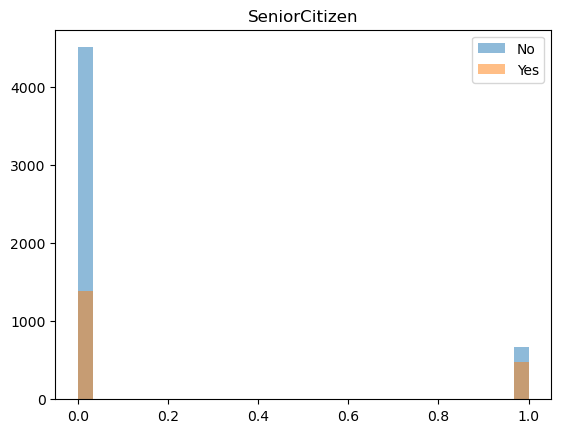

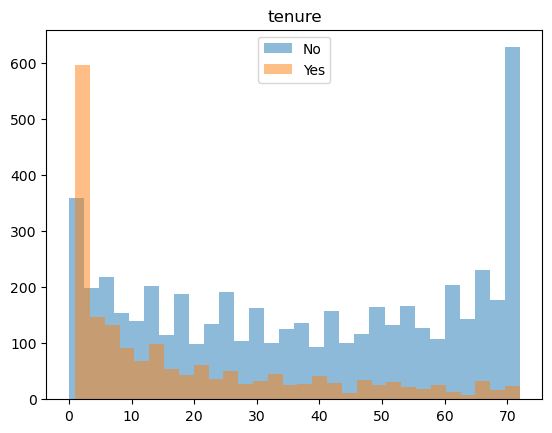

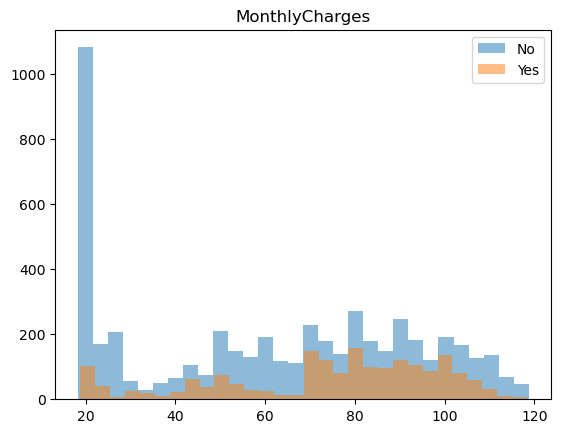

In [6]:
# Numeric Features vs Target
num_cols=[c for c in df.select_dtypes(include=np.number).columns][:3]
for col in num_cols:
    plt.figure()
    for cls in df[TARGET_COL].astype(str).unique():
        plt.hist(df[df[TARGET_COL].astype(str)==cls][col], bins=30, alpha=0.5, label=cls)
    plt.title(col)
    plt.legend()
    plt.show()


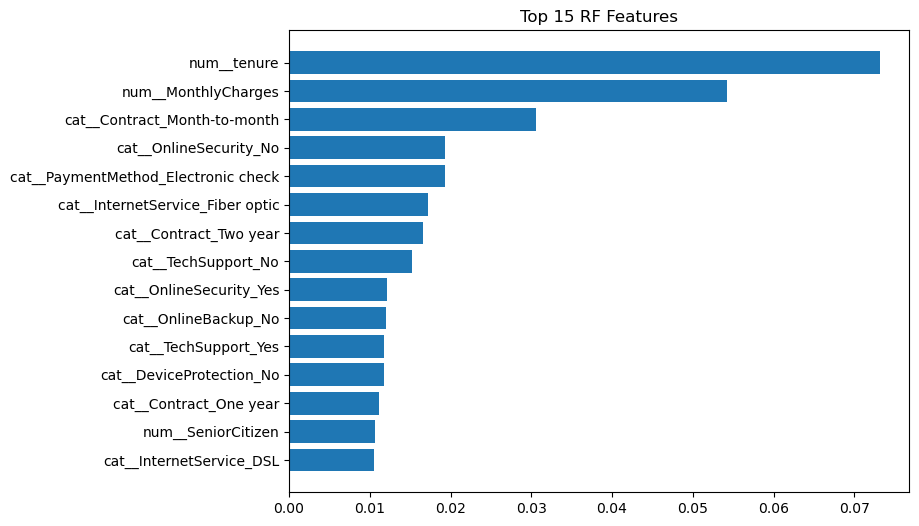

In [8]:
# RF Importance
X=df.drop(columns=[TARGET_COL])
y=df[TARGET_COL]

num_cols=X.select_dtypes(include=np.number).columns.tolist()
cat_cols=X.select_dtypes(exclude=np.number).columns.tolist()

pre=ColumnTransformer([
('num',Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]),num_cols),
('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('oh',OneHotEncoder(handle_unknown='ignore'))]),cat_cols)
])

Xp=pre.fit_transform(X)
rf=RandomForestClassifier(n_estimators=300,random_state=42)
rf.fit(Xp,y)

feat=pre.get_feature_names_out()
imp=pd.Series(rf.feature_importances_,index=feat).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
plt.barh(imp.index[::-1],imp.values[::-1])
plt.title('Top 15 RF Features')
plt.show()


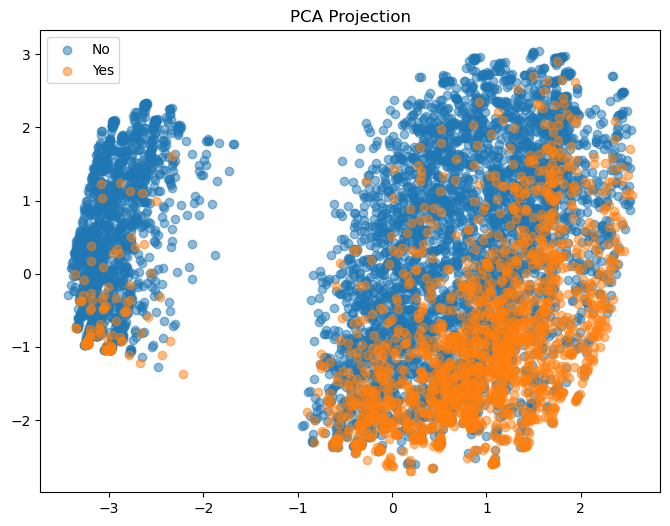

In [9]:
# PCA Separability Check
Xp_dense = Xp.toarray() if hasattr(Xp,'toarray') else Xp
pca=PCA(n_components=2)
coords=pca.fit_transform(Xp_dense)

plt.figure(figsize=(8,6))
for cls in pd.Series(y).astype(str).unique():
    mask=pd.Series(y).astype(str)==cls
    plt.scatter(coords[mask,0],coords[mask,1],alpha=0.5,label=cls)
plt.legend()
plt.title('PCA Projection')
plt.show()
